


# Grid-point linear regression for CO2 growth rates

This notebook fits one independent linear regression at each spatial grid point:

$$
\text{growth\_rate}(t,r)
=
\beta_0(r)
+
\beta_E(r)\,\text{emission}(t,r)
+
\beta_B(r)\,\text{gosif}(t,r)
+
\varepsilon(t,r),
$$

where $r=(\text{lat},\text{lon})$ and $t$ runs over the annual observations from 2015 to 2024.

The notebook:

1. Opens the NetCDF dataset.
2. Fills missing `emission` and `gosif` values with zero.
3. Fits one ordinary least-squares regression per grid cell.
4. Saves coefficient maps and predictions to a new NetCDF file.
5. Plots maps of $\beta_0$, $\beta_E$, $\beta_B$, $R^2$, RMSE, predictions, and residuals.

Put this notebook in the same folder as:

```text
unified_annual_carbon_dataset_2015_2024.nc
```

## 1. Install required packages

Run this once in the VS Code terminal if needed:

```powershell
pip install xarray netCDF4 numpy pandas matplotlib
```

Optional, for coastlines and political borders:

```powershell
pip install cartopy
```

The notebook works without `cartopy`; maps will simply be latitude-longitude plots.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Optional mapping library
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

print("Cartopy available:", HAS_CARTOPY)

Cartopy available: False


## 2. Configuration

In [2]:
INPUT_FILE = Path("unified_annual_carbon_dataset_2015_2024.nc")

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = Path("figures")

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

OUTPUT_NC = OUTPUT_DIR / "gridpoint_regression_growth_rate_from_emission_gosif_fill0.nc"
OUTPUT_CSV = OUTPUT_DIR / "gridpoint_regression_coefficients_flat.csv"

TARGET_VAR = "growth_rate"
EMISSION_VAR = "emission"
BIO_VAR = "gosif"

# Your dataset has 10 annual points.
# MIN_OBS = 10 requires all 10 growth_rate values to be valid.
MIN_OBS = 10

# Missing drivers are interpreted as zero.
FILL_MISSING_DRIVERS_WITH_ZERO = True

# If a predictor is temporally constant, its coefficient cannot be estimated.
# We set that coefficient to zero.
STD_TOL = 1e-12

print("Input file:", INPUT_FILE.resolve())
print("Output NetCDF:", OUTPUT_NC.resolve())

Input file: D:\2026\Complexity72h\unified_annual_carbon_dataset_2015_2024.nc
Output NetCDF: D:\2026\Complexity72h\outputs\gridpoint_regression_growth_rate_from_emission_gosif_fill0.nc


## 3. Open and inspect the dataset

In [3]:
ds = xr.open_dataset(INPUT_FILE)
ds

<xarray.Dataset> Size: 29MB
Dimensions:         (time: 10, lat: 180, lon: 360, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) int64 80B 2015 2016 2017 2018 ... 2021 2022 2023 2024
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    growth_rate     (time, lat, lon) float64 5MB ...
    emission        (time, lat, lon) float32 3MB ...
    gosif           (time, lat, lon) float32 3MB ...
    delta_emission  (time, lat, lon) float32 3MB ...
    delta_gosif     (time, lat, lon) float32 3MB ...
    cams_xco2       (time, latitude, longitude) float32 3MB ...
    growth_err      (time, lat, lon) float64 5MB ...
    mean_co2        (time, lat, lon) float64 5MB ...
Attributes:
    description:  Unified annual carbon dataset on growth-rate grid. Contains...

In [4]:
print("Variables:")
for var in ds.data_vars:
    print(f"- {var}: {ds[var].dims}, shape={ds[var].shape}")

print("\nCoordinates:")
for coord in ds.coords:
    print(f"- {coord}: shape={ds[coord].shape}")

Variables:
- growth_rate: ('time', 'lat', 'lon'), shape=(10, 180, 360)
- emission: ('time', 'lat', 'lon'), shape=(10, 180, 360)
- gosif: ('time', 'lat', 'lon'), shape=(10, 180, 360)
- delta_emission: ('time', 'lat', 'lon'), shape=(10, 180, 360)
- delta_gosif: ('time', 'lat', 'lon'), shape=(10, 180, 360)
- cams_xco2: ('time', 'latitude', 'longitude'), shape=(10, 180, 360)
- growth_err: ('time', 'lat', 'lon'), shape=(10, 180, 360)
- mean_co2: ('time', 'lat', 'lon'), shape=(10, 180, 360)

Coordinates:
- lat: shape=(180,)
- lon: shape=(360,)
- time: shape=(10,)
- longitude: shape=(360,)
- latitude: shape=(180,)


## 4. Extract target and drivers

We use:

$$Y(t,r)=\texttt{growth\_rate}(t,r),$$

$$E(t,r)=\texttt{emission}(t,r),$$

$$B(t,r)=\texttt{gosif}(t,r).$$

Missing `emission` and `gosif` values are filled with zero. Missing `growth_rate` values are **not** filled, because `growth_rate` is the variable being predicted.

In [5]:
y_da = ds[TARGET_VAR].transpose("time", "lat", "lon")
emission_da = ds[EMISSION_VAR].transpose("time", "lat", "lon")
bio_da = ds[BIO_VAR].transpose("time", "lat", "lon")

if FILL_MISSING_DRIVERS_WITH_ZERO:
    emission_da = emission_da.fillna(0)
    bio_da = bio_da.fillna(0)

print("Target:", TARGET_VAR, y_da.shape)
print("Emission:", EMISSION_VAR, emission_da.shape)
print("BIO:", BIO_VAR, bio_da.shape)

print("\nFraction finite:")
print("growth_rate:", float(np.isfinite(y_da).mean()))
print("emission after fill:", float(np.isfinite(emission_da).mean()))
print("gosif after fill:", float(np.isfinite(bio_da).mean()))

Target: growth_rate (10, 180, 360)
Emission: emission (10, 180, 360)
BIO: gosif (10, 180, 360)

Fraction finite:
growth_rate: 1.0
emission after fill: 1.0
gosif after fill: 1.0


## 5. Define the local OLS regression

At each grid cell, we fit:

$$Y = X\beta + \varepsilon,$$

where the design matrix contains an intercept column, an emission column, and a GOSIF column.

If `emission` or `gosif` is constant through time at a grid cell, its coefficient is not identifiable. In that case, we exclude that predictor from the local design matrix and set its coefficient to zero.

In [6]:
def fit_one_grid_point(y, emission, bio, min_obs=10, std_tol=1e-12):
    # Fit: growth_rate(t,r) = beta0(r) + beta_E(r)*emission(t,r) + beta_B(r)*gosif(t,r)
    # Missing emission and gosif values should already have been replaced by 0.

    y = np.asarray(y, dtype=float)
    emission = np.asarray(emission, dtype=float)
    bio = np.asarray(bio, dtype=float)

    # Only the target variable determines valid observations.
    valid = np.isfinite(y) & np.isfinite(emission) & np.isfinite(bio)

    n_obs = int(np.sum(valid))
    y_pred = np.full_like(y, np.nan, dtype=float)

    if n_obs < min_obs:
        return np.nan, np.nan, np.nan, np.nan, np.nan, n_obs, 0, 0, y_pred

    yv = y[valid]
    ev = emission[valid]
    bv = bio[valid]

    X_columns = [np.ones(n_obs)]
    column_names = ["intercept"]

    use_emission = np.nanstd(ev) > std_tol
    if use_emission:
        X_columns.append(ev)
        column_names.append("emission")

    use_bio = np.nanstd(bv) > std_tol
    if use_bio:
        X_columns.append(bv)
        column_names.append("bio")

    X = np.column_stack(X_columns)
    rank = np.linalg.matrix_rank(X)
    n_predictors_used = len(column_names) - 1

    beta_active, _, _, _ = np.linalg.lstsq(X, yv, rcond=None)

    beta0 = beta_active[0]
    beta_E = 0.0
    beta_B = 0.0

    idx = 1
    if use_emission:
        beta_E = beta_active[idx]
        idx += 1

    if use_bio:
        beta_B = beta_active[idx]

    pred_valid = np.isfinite(emission) & np.isfinite(bio)

    y_pred[pred_valid] = beta0 + beta_E * emission[pred_valid] + beta_B * bio[pred_valid]

    residuals = yv - (beta0 + beta_E * ev + beta_B * bv)

    rss = np.sum(residuals ** 2)
    tss = np.sum((yv - np.mean(yv)) ** 2)

    r2 = 1.0 - rss / tss if tss > 0 else np.nan
    rmse = np.sqrt(np.mean(residuals ** 2))

    return beta0, beta_E, beta_B, r2, rmse, n_obs, n_predictors_used, rank, y_pred

## 6. Fit one regression per grid cell

This loop goes over all $180\times360=64800$ grid cells. For each grid cell, it uses the 10 annual values to estimate:

$$\beta_0(r),\quad \beta_E(r),\quad \beta_B(r).$$

In [7]:
y = y_da.values
emission = emission_da.values
bio = bio_da.values

n_time, n_lat, n_lon = y.shape
n_grid = n_lat * n_lon

print(f"Number of years: {n_time}")
print(f"Number of latitudes: {n_lat}")
print(f"Number of longitudes: {n_lon}")
print(f"Number of grid cells: {n_grid}")

y_flat = y.reshape(n_time, n_grid)
emission_flat = emission.reshape(n_time, n_grid)
bio_flat = bio.reshape(n_time, n_grid)

beta0_flat = np.full(n_grid, np.nan)
beta_E_flat = np.full(n_grid, np.nan)
beta_B_flat = np.full(n_grid, np.nan)
r2_flat = np.full(n_grid, np.nan)
rmse_flat = np.full(n_grid, np.nan)
n_obs_flat = np.zeros(n_grid, dtype=np.int16)
n_predictors_used_flat = np.zeros(n_grid, dtype=np.int16)
rank_flat = np.zeros(n_grid, dtype=np.int16)

y_pred_flat = np.full((n_time, n_grid), np.nan)

for k in range(n_grid):
    beta0, beta_E, beta_B, r2, rmse, n_obs, n_predictors_used, rank, y_pred = fit_one_grid_point(
        y_flat[:, k],
        emission_flat[:, k],
        bio_flat[:, k],
        min_obs=MIN_OBS,
        std_tol=STD_TOL,
    )

    beta0_flat[k] = beta0
    beta_E_flat[k] = beta_E
    beta_B_flat[k] = beta_B
    r2_flat[k] = r2
    rmse_flat[k] = rmse
    n_obs_flat[k] = n_obs
    n_predictors_used_flat[k] = n_predictors_used
    rank_flat[k] = rank
    y_pred_flat[:, k] = y_pred

    if (k + 1) % 10000 == 0:
        print(f"Processed {k + 1} / {n_grid} grid cells")

print("Done fitting regressions.")
print("Valid fitted beta0 values:", np.isfinite(beta0_flat).sum())

Number of years: 10
Number of latitudes: 180
Number of longitudes: 360
Number of grid cells: 64800
Processed 10000 / 64800 grid cells
Processed 20000 / 64800 grid cells
Processed 30000 / 64800 grid cells
Processed 40000 / 64800 grid cells
Processed 50000 / 64800 grid cells
Processed 60000 / 64800 grid cells
Done fitting regressions.
Valid fitted beta0 values: 64800


## 7. Build the output gridded dataset

We reshape the flattened coefficients back into latitude-longitude maps.

In [9]:
beta0 = beta0_flat.reshape(n_lat, n_lon)
beta_E = beta_E_flat.reshape(n_lat, n_lon)
beta_B = beta_B_flat.reshape(n_lat, n_lon)
r2 = r2_flat.reshape(n_lat, n_lon)
rmse = rmse_flat.reshape(n_lat, n_lon)
n_obs = n_obs_flat.reshape(n_lat, n_lon)
n_predictors_used = n_predictors_used_flat.reshape(n_lat, n_lon)
rank = rank_flat.reshape(n_lat, n_lon)

predicted_growth_rate = y_pred_flat.reshape(n_time, n_lat, n_lon)
residual_growth_rate = y - predicted_growth_rate

out = xr.Dataset(
    data_vars={
        "beta0": (("lat", "lon"), beta0),
        "beta_E": (("lat", "lon"), beta_E),
        "beta_B": (("lat", "lon"), beta_B),
        "r2": (("lat", "lon"), r2),
        "rmse": (("lat", "lon"), rmse),
        "n_obs": (("lat", "lon"), n_obs),
        "n_predictors_used": (("lat", "lon"), n_predictors_used),
        "design_matrix_rank": (("lat", "lon"), rank),
        "predicted_growth_rate": (("time", "lat", "lon"), predicted_growth_rate),
        "residual_growth_rate": (("time", "lat", "lon"), residual_growth_rate),
        "emission_filled0": (("time", "lat", "lon"), emission),
        "gosif_filled0": (("time", "lat", "lon"), bio),
    },
    coords={
        "time": y_da["time"].values,
        "lat": y_da["lat"].values,
        "lon": y_da["lon"].values,
    },
    attrs={
        "title": "Grid-point linear regression of CO2 growth rate from emission and GOSIF",
        "model": "growth_rate(t,r) = beta0(r) + beta_E(r) * emission(t,r) + beta_B(r) * gosif(t,r)",
        "target_variable": TARGET_VAR,
        "emission_variable": EMISSION_VAR,
        "biospheric_variable": BIO_VAR,
        "missing_emission_handling": "NaN values filled with 0 before regression",
        "missing_gosif_handling": "NaN values filled with 0 before regression",
        "minimum_observations": MIN_OBS,
        "coefficient_note": "If a predictor is temporally constant at a grid point, its coefficient is set to 0.",
    },
)

out["beta0"].attrs["long_name"] = "Intercept of local linear regression"
out["beta_E"].attrs["long_name"] = "Emission regression coefficient"
out["beta_B"].attrs["long_name"] = "GOSIF regression coefficient"
out["r2"].attrs["long_name"] = "Coefficient of determination"
out["rmse"].attrs["long_name"] = "Root mean squared error"
out["predicted_growth_rate"].attrs["long_name"] = "Predicted CO2 growth rate"
out["residual_growth_rate"].attrs["long_name"] = "Residual CO2 growth rate"

out

<xarray.Dataset> Size: 19MB
Dimensions:                (lat: 180, lon: 360, time: 10)
Coordinates:
  * lat                    (lat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                    (lon) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * time                   (time) int64 80B 2015 2016 2017 ... 2022 2023 2024
Data variables:
    beta0                  (lat, lon) float64 518kB 2.409 2.375 ... 2.521 2.521
    beta_E                 (lat, lon) float64 518kB 0.0 0.0 ... -0.2175 -0.2182
    beta_B                 (lat, lon) float64 518kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    r2                     (lat, lon) float64 518kB 0.0 0.0 ... 0.04482 0.04511
    rmse                   (lat, lon) float64 518kB 0.3104 0.3469 ... 0.3606
    n_obs                  (lat, lon) int16 130kB 10 10 10 10 10 ... 10 10 10 10
    n_predictors_used      (lat, lon) int16 130kB 0 0 0 0 0 0 0 ... 1 0 0 0 1 1
    design_matrix_rank     (lat, lon) int16 130kB 1 1 1 1 1 1 1 ... 2 1 1 1 2 2
    predicted_growth_rate  (time, lat, lon) float64 5MB 2.409 2.375 ... 2.521
    residual_growth_rate   (time, lat, lon) float64 5MB -0.1847 ... 0.6262
    emission_filled0       (time, lat, lon) float32 3MB 0.0 0.0 0.0 ... 0.0 0.0
    gosif_filled0          (time, lat, lon) float32 3MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    title:                      Grid-point linear regression of CO2 growth ra...
    model:                      growth_rate(t,r) = beta0(r) + beta_E(r) * emi...
    target_variable:            growth_rate
    emission_variable:          emission
    biospheric_variable:        gosif
    missing_emission_handling:  NaN values filled with 0 before regression
    missing_gosif_handling:     NaN values filled with 0 before regression
    minimum_observations:       10
    coefficient_note:           If a predictor is temporally constant at a gr...

## 8. Save the result

### Is NetCDF the best format?

For the main gridded result, **yes**. NetCDF is the best format here because the output naturally has dimensions:

$$\texttt{time}\times\texttt{lat}\times\texttt{lon}$$

and variables such as:

$$\beta_0(\texttt{lat},\texttt{lon}),\quad \beta_E(\texttt{lat},\texttt{lon}),\quad \beta_B(\texttt{lat},\texttt{lon}).$$

NetCDF preserves coordinates, metadata, and multidimensional structure. For clustering later, a flattened CSV or Parquet table is also useful, so this notebook saves both:

- `.nc` for maps and geophysical analysis,
- `.csv` for clustering / machine learning.

In [11]:
encoding = {var: {"zlib": True, "complevel": 4} for var in out.data_vars}
out.to_netcdf(OUTPUT_NC, encoding=encoding)
print("Saved NetCDF:", OUTPUT_NC)

flat = out[["beta0", "beta_E", "beta_B", "r2", "rmse", "n_obs", "n_predictors_used", "design_matrix_rank"]].to_dataframe().reset_index()
flat.to_csv(OUTPUT_CSV, index=False)
print("Saved flattened CSV:", OUTPUT_CSV)

flat.head()

Saved NetCDF: outputs\gridpoint_regression_growth_rate_from_emission_gosif_fill0.nc
Saved flattened CSV: outputs\gridpoint_regression_coefficients_flat.csv


,lat,lon,beta0,beta_E,beta_B,r2,rmse,n_obs,n_predictors_used,design_matrix_rank
0,-89.5,-179.5,2.408877,0.0,0.0,0.0,0.310373,10,0,1
1,-89.5,-178.5,2.375181,0.0,0.0,0.0,0.346935,10,0,1
2,-89.5,-177.5,2.408885,0.0,0.0,0.0,0.310389,10,0,1
3,-89.5,-176.5,2.408896,0.0,0.0,0.0,0.310344,10,0,1
4,-89.5,-175.5,2.408902,0.0,0.0,0.0,0.310335,10,0,1


## 9. Map plotting function

In [12]:
def plot_map_xarray(da, title=None, cmap="coolwarm", robust=True, save_path=None):
    if title is None:
        title = da.name

    if HAS_CARTOPY:
        fig = plt.figure(figsize=(13, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        da.plot(
            ax=ax,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            robust=robust,
            cbar_kwargs={"label": da.name},
        )
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.set_global()
        ax.set_title(title)
    else:
        plt.figure(figsize=(12, 5))
        da.plot(x="lon", y="lat", cmap=cmap, robust=robust, cbar_kwargs={"label": da.name})
        plt.title(title)
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

## 10. Plot coefficient maps

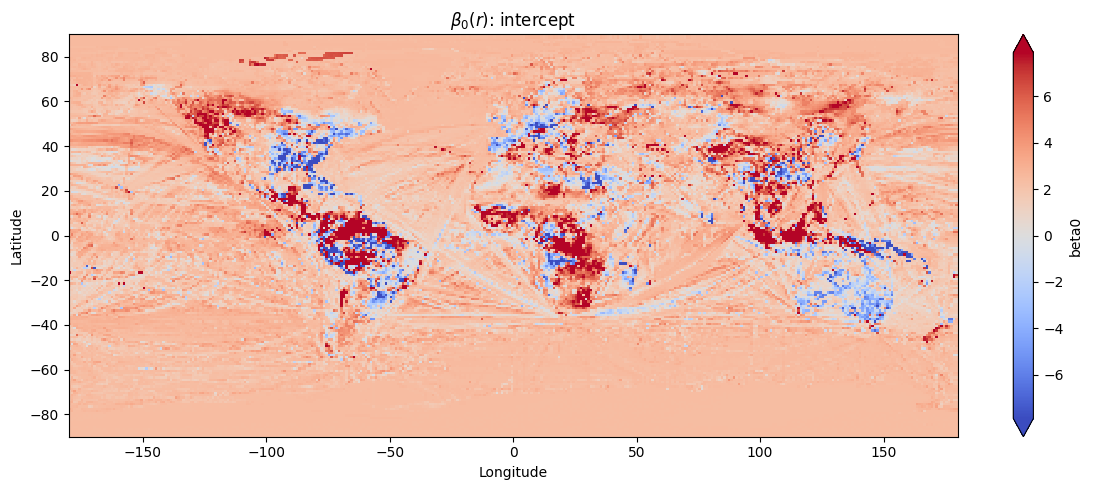

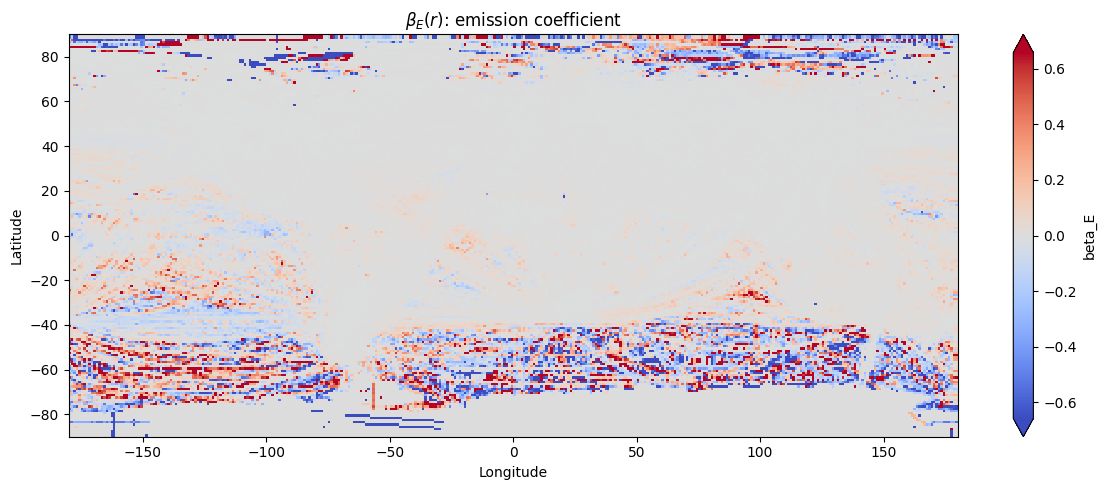

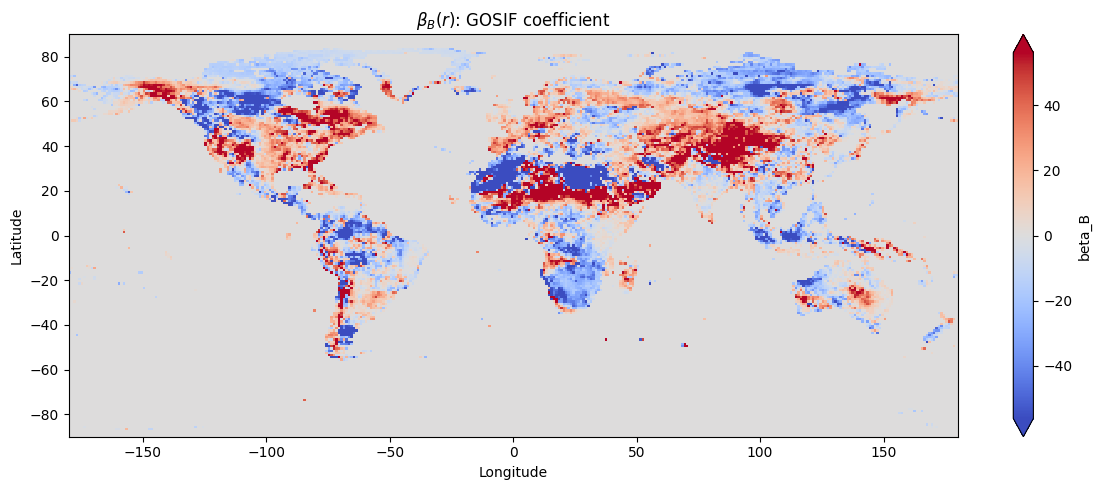

In [13]:
plot_map_xarray(out["beta0"], title=r"$\beta_0(r)$: intercept", cmap="coolwarm", save_path=FIGURE_DIR / "beta0_map_fill0.png")
plot_map_xarray(out["beta_E"], title=r"$\beta_E(r)$: emission coefficient", cmap="coolwarm", save_path=FIGURE_DIR / "beta_E_map_fill0.png")
plot_map_xarray(out["beta_B"], title=r"$\beta_B(r)$: GOSIF coefficient", cmap="coolwarm", save_path=FIGURE_DIR / "beta_B_map_fill0.png")

## 11. Plot model-quality maps

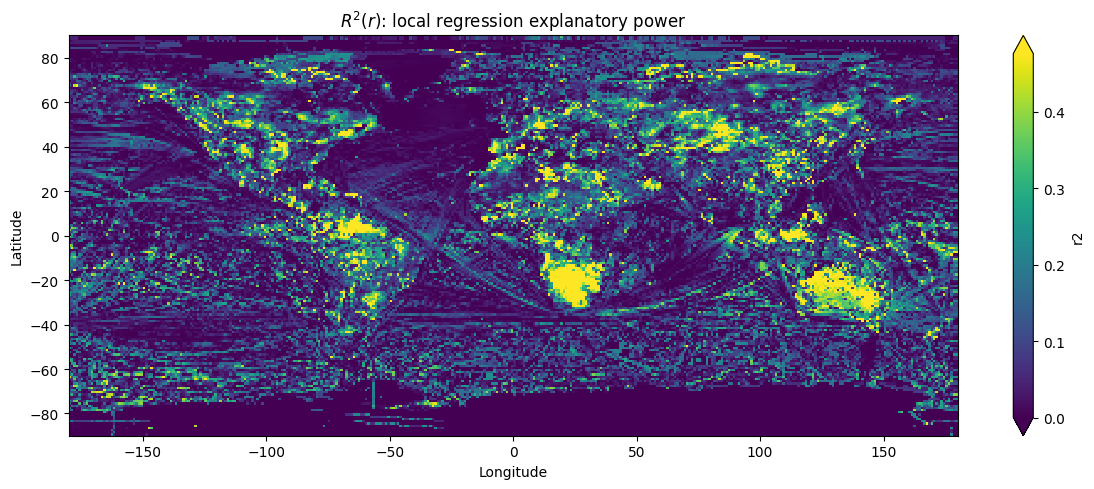

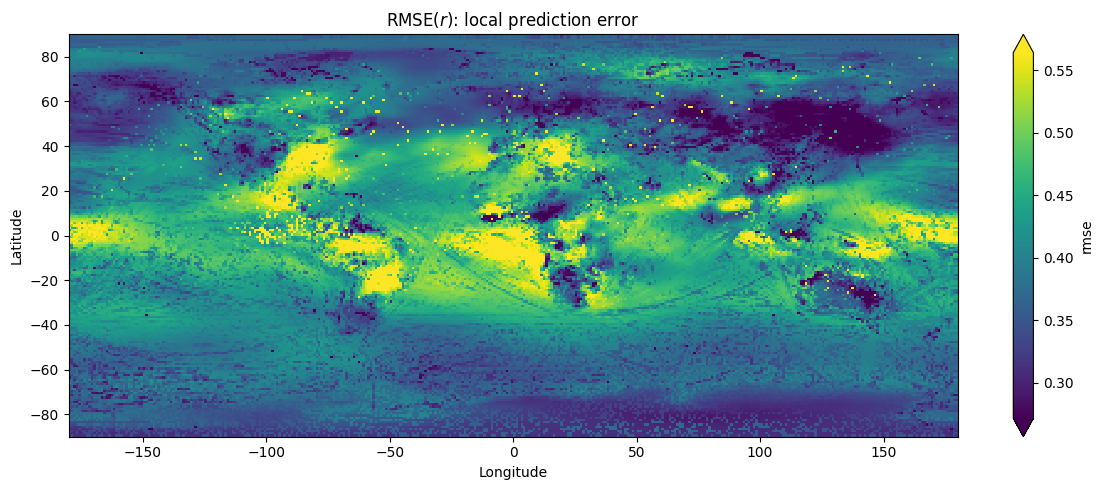

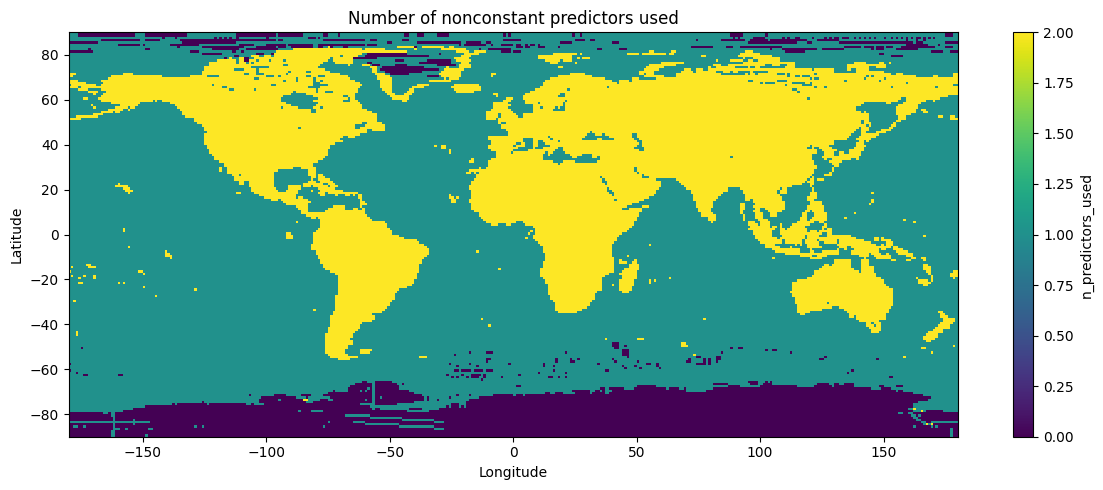

In [14]:
plot_map_xarray(out["r2"], title=r"$R^2(r)$: local regression explanatory power", cmap="viridis", save_path=FIGURE_DIR / "r2_map_fill0.png")
plot_map_xarray(out["rmse"], title=r"RMSE$(r)$: local prediction error", cmap="viridis", save_path=FIGURE_DIR / "rmse_map_fill0.png")
plot_map_xarray(out["n_predictors_used"], title="Number of nonconstant predictors used", cmap="viridis", robust=False, save_path=FIGURE_DIR / "n_predictors_used_map_fill0.png")

## 12. Plot observed, predicted, and residual growth rate for one year

Change `YEAR_TO_PLOT` to inspect another year.

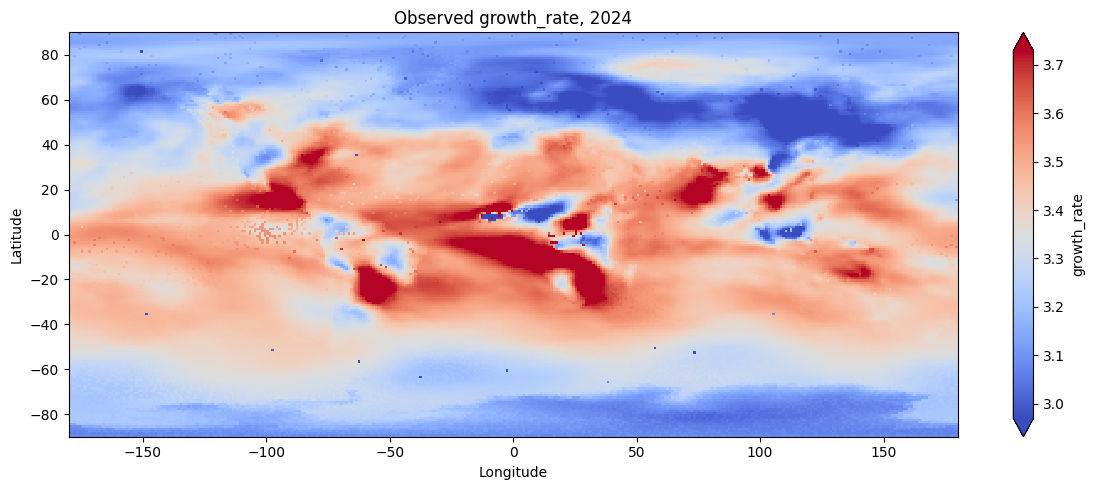

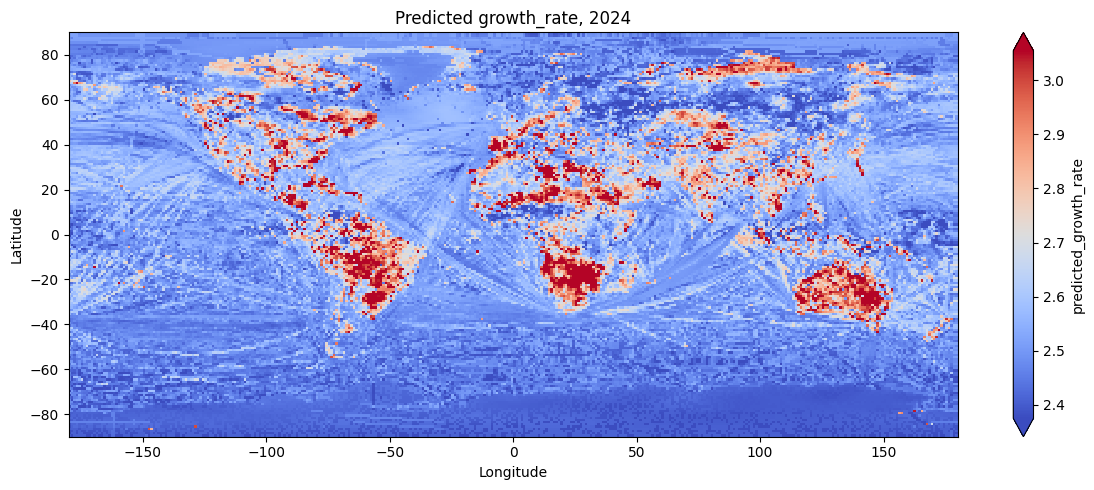

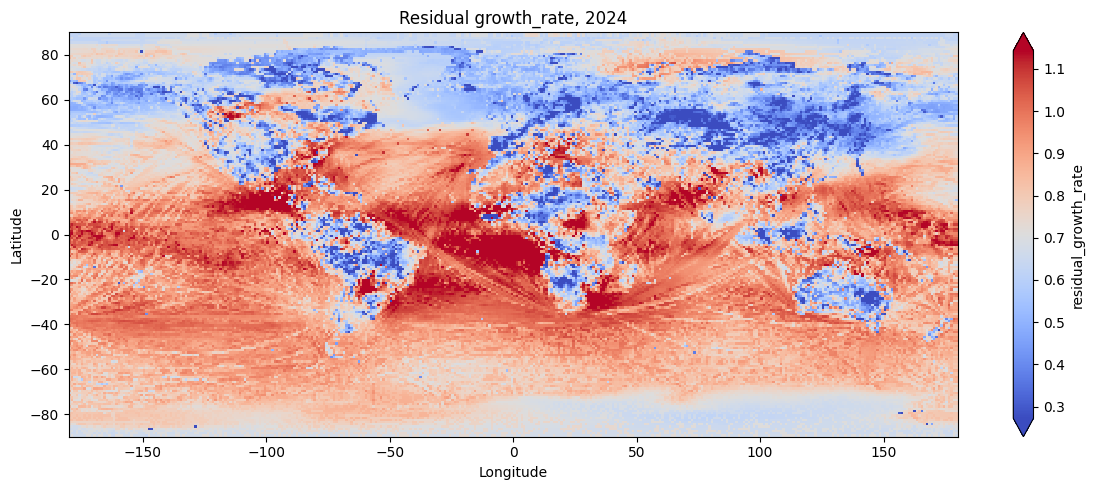

In [18]:
YEAR_TO_PLOT = 2024

observed = y_da.sel(time=YEAR_TO_PLOT)
predicted = out["predicted_growth_rate"].sel(time=YEAR_TO_PLOT)
residual = out["residual_growth_rate"].sel(time=YEAR_TO_PLOT)

plot_map_xarray(observed, title=f"Observed growth_rate, {YEAR_TO_PLOT}", cmap="coolwarm", save_path=FIGURE_DIR / f"observed_growth_rate_{YEAR_TO_PLOT}.png")
plot_map_xarray(predicted, title=f"Predicted growth_rate, {YEAR_TO_PLOT}", cmap="coolwarm", save_path=FIGURE_DIR / f"predicted_growth_rate_{YEAR_TO_PLOT}.png")
plot_map_xarray(residual, title=f"Residual growth_rate, {YEAR_TO_PLOT}", cmap="coolwarm", save_path=FIGURE_DIR / f"residual_growth_rate_{YEAR_TO_PLOT}.png")

## 13. Quick global summary of coefficients

In [ ]:
summary_vars = ["beta0", "beta_E", "beta_B", "r2", "rmse", "n_predictors_used"]
summary = {}

for var in summary_vars:
    values = out[var].values
    finite = values[np.isfinite(values)]
    summary[var] = {
        "n_finite": finite.size,
        "mean": np.nanmean(values),
        "std": np.nanstd(values),
        "min": np.nanmin(values),
        "q05": np.nanquantile(values, 0.05),
        "median": np.nanmedian(values),
        "q95": np.nanquantile(values, 0.95),
        "max": np.nanmax(values),
    }

summary_df = pd.DataFrame(summary).T
summary_df

## 14. Optional: inspect one local regression

This lets you choose a point by latitude and longitude and compare observed and predicted `growth_rate`.

In [ ]:
LAT0 = 40.4
LON0 = -3.7

local_obs = y_da.sel(lat=LAT0, lon=LON0, method="nearest")
local_pred = out["predicted_growth_rate"].sel(lat=LAT0, lon=LON0, method="nearest")
local_resid = out["residual_growth_rate"].sel(lat=LAT0, lon=LON0, method="nearest")

local_beta0 = out["beta0"].sel(lat=LAT0, lon=LON0, method="nearest").item()
local_beta_E = out["beta_E"].sel(lat=LAT0, lon=LON0, method="nearest").item()
local_beta_B = out["beta_B"].sel(lat=LAT0, lon=LON0, method="nearest").item()
local_r2 = out["r2"].sel(lat=LAT0, lon=LON0, method="nearest").item()

print("Nearest grid point:")
print("lat =", float(local_obs["lat"]))
print("lon =", float(local_obs["lon"]))
print("beta0 =", local_beta0)
print("beta_E =", local_beta_E)
print("beta_B =", local_beta_B)
print("R2 =", local_r2)

plt.figure(figsize=(8, 4))
plt.plot(local_obs["time"], local_obs, marker="o", label="Observed growth_rate")
plt.plot(local_pred["time"], local_pred, marker="o", label="Predicted growth_rate")
plt.axhline(0, linewidth=0.8)
plt.title(f"Observed vs predicted growth_rate near lat={LAT0}, lon={LON0}")
plt.xlabel("Year")
plt.ylabel("growth_rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(local_resid["time"], local_resid, marker="o")
plt.axhline(0, linewidth=0.8)
plt.title(f"Residual growth_rate near lat={LAT0}, lon={LON0}")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Interpretation notes

- $\beta_E(r)$ is the local statistical association between annual emissions and annual CO2 growth rate.
- $\beta_B(r)$ is the local statistical association between annual GOSIF and annual CO2 growth rate.
- $R^2(r)$ measures how much of the local temporal variation in `growth_rate` is explained by `emission` and `gosif`.
- Coefficients should not be interpreted as direct causal flux sensitivities because atmospheric CO2 is transported and mixed.
- Each regression uses only 10 annual points, so coefficient maps should be interpreted as exploratory statistical fingerprints.



C:\Users\adrig\AppData\Local\Temp\ipykernel_6104\997689508.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


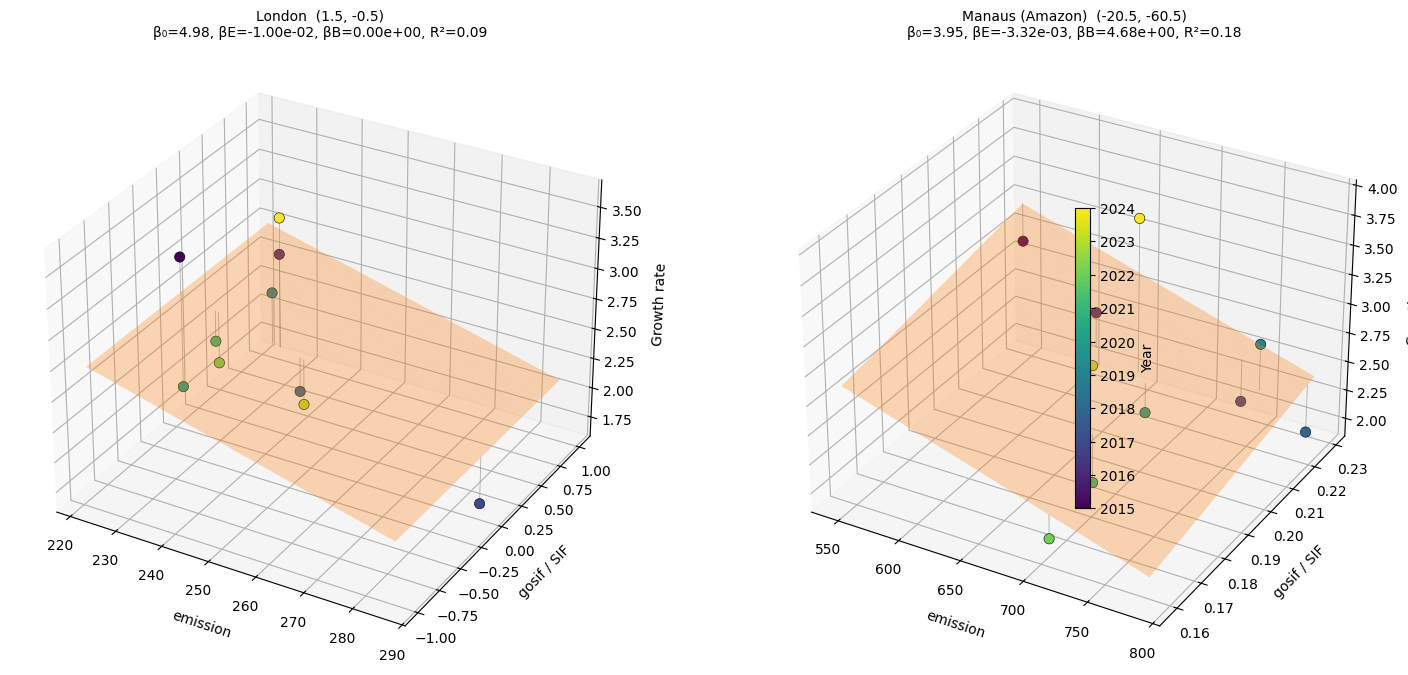

In [ ]:
# --- 3D scatter of the 10 yearly points + fitted regression plane, per site ---

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------------
# Sites to inspect
# ------------------------------------------------------------

SITES = {
    "London": (51.5074, -0.1278),
    "Manaus (Amazon)": (-3.119, -60.022),
}

# ------------------------------------------------------------
# Load source dataset and coefficient dataset
# ------------------------------------------------------------

# Use already-open source dataset if available; otherwise open from disk
try:
    ds
except NameError:
    ds = xr.open_dataset(INPUT_FILE)

# Use already-computed regression output if available; otherwise open from disk
try:
    coef = out
except NameError:
    coef = xr.open_dataset(OUTPUT_NC)

# ------------------------------------------------------------
# Variable names
# ------------------------------------------------------------

target_name = TARGET_VAR       # usually "growth_rate"
emission_name = EMISSION_VAR   # usually "emission"
bio_name = BIO_VAR             # usually "gosif"

# In our regression notebook, missing drivers were filled with zero
# and stored inside the output dataset. Use those fields if available.
if "emission_filled0" in coef:
    emission_field = coef["emission_filled0"]
else:
    emission_field = ds[emission_name].fillna(0)

if "gosif_filled0" in coef:
    bio_field = coef["gosif_filled0"]
else:
    bio_field = ds[bio_name].fillna(0)

target_field = ds[target_name]

# ------------------------------------------------------------
# Important:
# The notebook regression fitted raw growth_rate, not growth-rate anomaly.
# Therefore we should not subtract the global mean here.
# ------------------------------------------------------------

USE_GLOBAL_MEAN_ANOMALY = False

if USE_GLOBAL_MEAN_ANOMALY:
    weights = np.cos(np.deg2rad(ds["lat"]))
    global_mean = target_field.weighted(weights).mean(dim=("lat", "lon"))
else:
    global_mean = xr.zeros_like(target_field.mean(dim=("lat", "lon")))

# Years for colorbar
years = ds["time"].values

# Convert years to numeric values for matplotlib coloring
# This works whether time is integer years or datetime-like.
if np.issubdtype(years.dtype, np.datetime64):
    years_numeric = years.astype("datetime64[Y]").astype(int) + 1970
else:
    years_numeric = years.astype(float)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(15, 6.5))

last_scatter = None

for i, (name, (la, lo)) in enumerate(SITES.items(), start=1):

    # Select nearest grid point
    y_cell = target_field.sel(lat=la, lon=lo, method="nearest")
    e_cell = emission_field.sel(lat=la, lon=lo, method="nearest")
    b_cell = bio_field.sel(lat=la, lon=lo, method="nearest")
    gm_cell = global_mean

    c = coef.sel(lat=la, lon=lo, method="nearest")

    # Extract local time series
    E = e_cell.values.astype(float)
    B = b_cell.values.astype(float)
    g = (y_cell - gm_cell).values.astype(float)

    # Extract fitted coefficients
    b0 = float(c["beta0"].values)
    bE = float(c["beta_E"].values)
    bB = float(c["beta_B"].values)
    r2 = float(c["r2"].values)

    # Valid observations
    valid = np.isfinite(E) & np.isfinite(B) & np.isfinite(g)

    E_valid = E[valid]
    B_valid = B[valid]
    g_valid = g[valid]
    years_valid = years_numeric[valid]

    ax = fig.add_subplot(1, len(SITES), i, projection="3d")

    if len(E_valid) == 0:
        ax.set_title(f"{name}\nNo valid data")
        continue

    # --------------------------------------------------------
    # Fitted plane:
    # z = beta0 + beta_E * emission + beta_B * gosif
    # --------------------------------------------------------

    # If a predictor is constant, expand the plotting range a little
    E_min, E_max = np.nanmin(E_valid), np.nanmax(E_valid)
    B_min, B_max = np.nanmin(B_valid), np.nanmax(B_valid)

    if E_min == E_max:
        delta = 1.0 if E_min == 0 else 0.05 * abs(E_min)
        E_min -= delta
        E_max += delta

    if B_min == B_max:
        delta = 1.0 if B_min == 0 else 0.05 * abs(B_min)
        B_min -= delta
        B_max += delta

    Eg = np.linspace(E_min, E_max, 12)
    Bg = np.linspace(B_min, B_max, 12)

    EE, BB = np.meshgrid(Eg, Bg)
    ZZ = b0 + bE * EE + bB * BB

    ax.plot_surface(
        EE,
        BB,
        ZZ,
        alpha=0.30,
        color="tab:orange",
        edgecolor="none",
        shade=False,
    )

    # --------------------------------------------------------
    # Scatter observed yearly points
    # --------------------------------------------------------

    last_scatter = ax.scatter(
        E_valid,
        B_valid,
        g_valid,
        c=years_valid,
        cmap="viridis",
        s=55,
        depthshade=False,
        edgecolor="k",
        linewidth=0.4,
    )

    # Vertical residual lines from observed point to fitted plane
    for ei, bi, gi in zip(E_valid, B_valid, g_valid):
        zi_pred = b0 + bE * ei + bB * bi
        ax.plot(
            [ei, ei],
            [bi, bi],
            [gi, zi_pred],
            color="gray",
            lw=0.6,
            alpha=0.6,
        )

    nearest_lat = float(y_cell["lat"].values)
    nearest_lon = float(y_cell["lon"].values)

    ax.set_xlabel(f"\n{emission_name}")
    ax.set_ylabel(f"\n{bio_name} / SIF")

    if USE_GLOBAL_MEAN_ANOMALY:
        ax.set_zlabel("\nGrowth-rate anomaly")
    else:
        ax.set_zlabel("\nGrowth rate")

    ax.set_title(
        f"{name}  ({nearest_lat:.1f}, {nearest_lon:.1f})\n"
        f"β₀={b0:.2f}, βE={bE:.2e}, βB={bB:.2e}, R²={r2:.2f}",
        fontsize=10,
    )

if last_scatter is not None:
    cbar = fig.colorbar(
        last_scatter,
        ax=fig.axes,
        shrink=0.6,
        pad=0.08,
    )
    cbar.set_label("Year")

plt.tight_layout()
plt.show()